In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [2]:
raw_dir = Path("../data/raw")

files = [
    raw_dir / "flights_2025_01_departure.csv",
    raw_dir / "flights_2025_02_departure.csv",
    raw_dir / "flights_2025_03_departure.csv",
]

dfs = []

for file in files:
    temp = pd.read_csv(file, low_memory=False)
    print(file.name, temp.shape)
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

df.shape

flights_2025_01_departure.csv (539747, 32)
flights_2025_02_departure.csv (504884, 32)
flights_2025_03_departure.csv (600872, 32)


(1645503, 32)

In [3]:
completed = df[
    (df["CANCELLED"] == 0) &
    (df["DIVERTED"] == 0) &
    (df["ARR_DEL15"].notna())
].copy()

completed.shape

(1611046, 32)

In [4]:
target = "ARR_DEL15"

numeric_features = [
    "MONTH",
    "DAY_OF_MONTH",
    "DAY_OF_WEEK",
    "CRS_DEP_TIME",
    "CRS_ARR_TIME",
    "DISTANCE",
    "DISTANCE_GROUP",
    "DEP_DELAY",
    "DEP_DELAY_NEW",
    "DEP_DEL15",
    "DEP_DELAY_GROUP",
    "TAXI_OUT",
    "WHEELS_OFF"
]

categorical_features = [
    "OP_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST",
    "DEP_TIME_BLK",
    "ARR_TIME_BLK"
]

features = numeric_features + categorical_features

In [5]:
train_data = completed[completed["MONTH"] == 1].copy()
val_data = completed[completed["MONTH"] == 2].copy()
test_data = completed[completed["MONTH"] == 3].copy()

X_train = train_data[features]
y_train = train_data[target].astype(int)

X_val = val_data[features]
y_val = val_data[target].astype(int)

X_test = test_data[features]
y_test = test_data[target].astype(int)

X_train.shape, X_val.shape, X_test.shape

((522269, 18), (496476, 18), (592301, 18))

In [6]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer_dense = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

preprocessor_dense = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer_dense, categorical_features)
    ]
)

In [7]:
hgb_departure_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_dense),
        ("model", HistGradientBoostingClassifier(
            max_iter=100,
            learning_rate=0.1,
            max_leaf_nodes=31,
            random_state=42
        ))
    ]
)

hgb_departure_model.fit(X_train, y_train)

test_probs = hgb_departure_model.predict_proba(X_test)[:, 1]

In [8]:
best_threshold = 0.40

test_preds = (test_probs >= best_threshold).astype(int)

print("Departure-Delay Model: March Test")
print("Threshold:", best_threshold)
print("Accuracy:", accuracy_score(y_test, test_preds))
print("Precision:", precision_score(y_test, test_preds, zero_division=0))
print("Recall:", recall_score(y_test, test_preds, zero_division=0))
print("F1:", f1_score(y_test, test_preds, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, test_probs))

print()
print(classification_report(y_test, test_preds, zero_division=0))

Departure-Delay Model: March Test
Threshold: 0.4
Accuracy: 0.9446683358630156
Precision: 0.9029316969773227
Recall: 0.8039884861333747
F1: 0.8505924240835548
ROC-AUC: 0.9628379577861427

              precision    recall  f1-score   support

           0       0.95      0.98      0.97    476267
           1       0.90      0.80      0.85    116034

    accuracy                           0.94    592301
   macro avg       0.93      0.89      0.91    592301
weighted avg       0.94      0.94      0.94    592301



In [9]:
sample_size = 50000

X_test_sample = X_test.sample(
    n=sample_size,
    random_state=42
)

y_test_sample = y_test.loc[X_test_sample.index]

X_test_sample.shape, y_test_sample.shape

((50000, 18), (50000,))

In [10]:
perm_result = permutation_importance(
    hgb_departure_model,
    X_test_sample,
    y_test_sample,
    scoring="f1",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": features,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
})

importance_df = importance_df.sort_values(
    "importance_mean",
    ascending=False
)

importance_df

,feature,importance_mean,importance_std
7,DEP_DELAY,0.590152,0.004666
11,TAXI_OUT,0.100246,0.002994
5,DISTANCE,0.003831,0.000965
13,OP_UNIQUE_CARRIER,0.002453,0.000883
12,WHEELS_OFF,0.001806,0.000436
14,ORIGIN,0.001375,0.000412
17,ARR_TIME_BLK,0.000870,0.000248
2,DAY_OF_WEEK,0.000480,0.000295
1,DAY_OF_MONTH,0.000289,0.000083
10,DEP_DELAY_GROUP,0.000069,0.000151


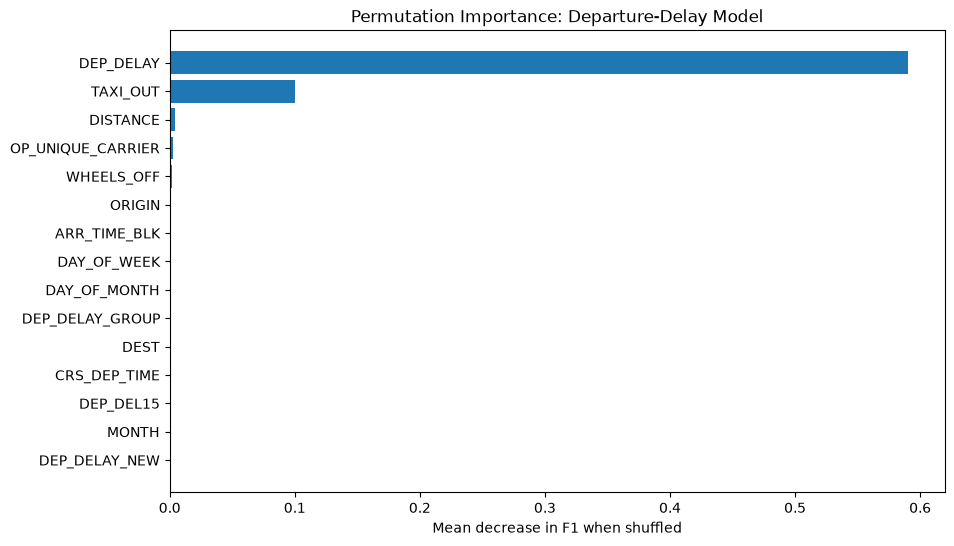

In [11]:
top_importance = importance_df.head(15).sort_values("importance_mean")

plt.figure(figsize=(10, 6))
plt.barh(top_importance["feature"], top_importance["importance_mean"])
plt.xlabel("Mean decrease in F1 when shuffled")
plt.title("Permutation Importance: Departure-Delay Model")
plt.show()

In [12]:
dep_group_delay = (
    test_data
    .groupby("DEP_DELAY_GROUP")["ARR_DEL15"]
    .agg(["count", "mean"])
    .sort_index()
)

dep_group_delay["arrival_late_rate_percent"] = dep_group_delay["mean"] * 100

dep_group_delay

,count,mean,arrival_late_rate_percent
DEP_DELAY_GROUP,,,
-2.0,4696,0.011499,1.149915
-1.0,362040,0.033889,3.388852
0.0,112363,0.111425,11.142458
1.0,37572,0.479639,47.963909
2.0,20968,0.890834,89.083365
3.0,13216,0.988272,98.827179
4.0,9038,0.998562,99.856163
5.0,6684,0.999701,99.970078
6.0,5075,1.000000,100.000000


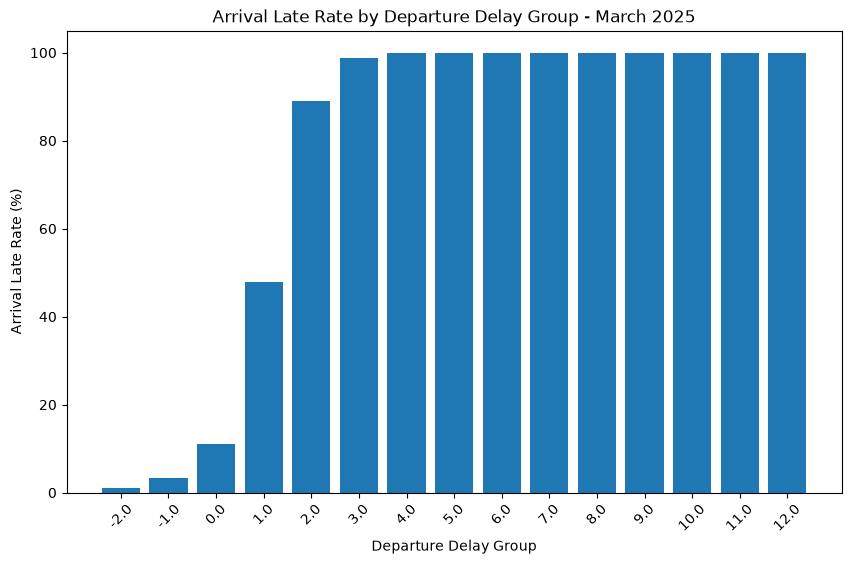

In [13]:
plot_data = dep_group_delay.reset_index()

plt.figure(figsize=(10, 6))
plt.bar(plot_data["DEP_DELAY_GROUP"].astype(str), plot_data["arrival_late_rate_percent"])
plt.xlabel("Departure Delay Group")
plt.ylabel("Arrival Late Rate (%)")
plt.title("Arrival Late Rate by Departure Delay Group - March 2025")
plt.xticks(rotation=45)
plt.show()

In [14]:
test_with_probs = test_data.copy()
test_with_probs["predicted_delay_probability"] = test_probs

prob_by_dep_group = (
    test_with_probs
    .groupby("DEP_DELAY_GROUP")["predicted_delay_probability"]
    .agg(["count", "mean"])
    .sort_index()
)

prob_by_dep_group["mean_predicted_probability_percent"] = prob_by_dep_group["mean"] * 100

prob_by_dep_group

,count,mean,mean_predicted_probability_percent
DEP_DELAY_GROUP,,,
-2.0,4696,0.015579,1.557864
-1.0,362040,0.031467,3.146750
0.0,112363,0.096140,9.613982
1.0,37572,0.414513,41.451325
2.0,20968,0.848057,84.805743
3.0,13216,0.981803,98.180261
4.0,9038,0.997089,99.708943
5.0,6684,0.999334,99.933373
6.0,5075,0.999422,99.942161


In [15]:
actual_vs_predicted = dep_group_delay[["arrival_late_rate_percent"]].join(
    prob_by_dep_group[["mean_predicted_probability_percent"]]
)

actual_vs_predicted

,arrival_late_rate_percent,mean_predicted_probability_percent
DEP_DELAY_GROUP,,
-2.0,1.149915,1.557864
-1.0,3.388852,3.146750
0.0,11.142458,9.613982
1.0,47.963909,41.451325
2.0,89.083365,84.805743
3.0,98.827179,98.180261
4.0,99.856163,99.708943
5.0,99.970078,99.933373
6.0,100.000000,99.942161


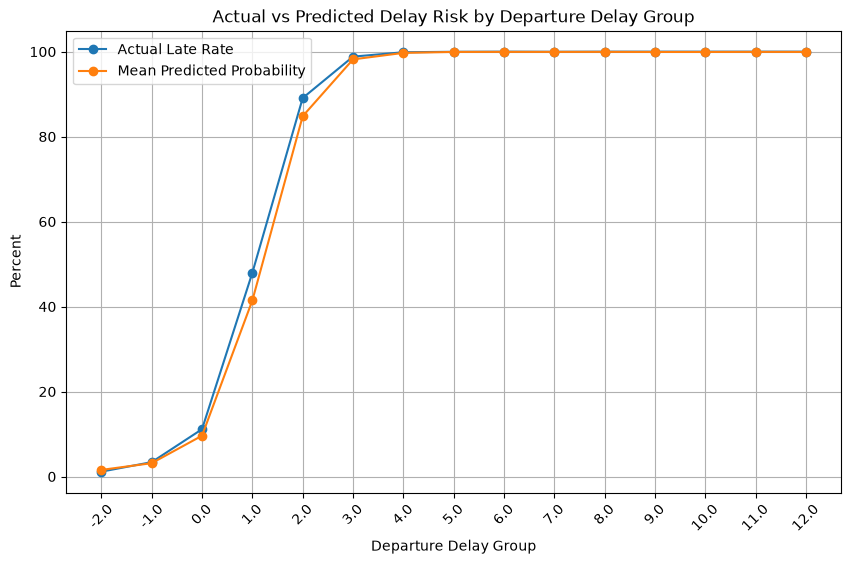

In [16]:
plot_data = actual_vs_predicted.reset_index()

plt.figure(figsize=(10, 6))
plt.plot(
    plot_data["DEP_DELAY_GROUP"].astype(str),
    plot_data["arrival_late_rate_percent"],
    marker="o",
    label="Actual Late Rate"
)
plt.plot(
    plot_data["DEP_DELAY_GROUP"].astype(str),
    plot_data["mean_predicted_probability_percent"],
    marker="o",
    label="Mean Predicted Probability"
)

plt.xlabel("Departure Delay Group")
plt.ylabel("Percent")
plt.title("Actual vs Predicted Delay Risk by Departure Delay Group")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

In [17]:
Path("../visuals").mkdir(exist_ok=True)

importance_df.to_csv(
    "../visuals/departure_model_permutation_importance.csv",
    index=False
)

dep_group_delay.to_csv(
    "../visuals/arrival_late_rate_by_departure_delay_group.csv"
)

actual_vs_predicted.to_csv(
    "../visuals/actual_vs_predicted_by_departure_delay_group.csv"
)

importance_df.head(15)

,feature,importance_mean,importance_std
7,DEP_DELAY,0.590152,0.004666
11,TAXI_OUT,0.100246,0.002994
5,DISTANCE,0.003831,0.000965
13,OP_UNIQUE_CARRIER,0.002453,0.000883
12,WHEELS_OFF,0.001806,0.000436
14,ORIGIN,0.001375,0.000412
17,ARR_TIME_BLK,0.000870,0.000248
2,DAY_OF_WEEK,0.000480,0.000295
1,DAY_OF_MONTH,0.000289,0.000083
10,DEP_DELAY_GROUP,0.000069,0.000151


The model interpretation confirms that departure delay is the dominant predictor of arrival delay. Permutation importance showed that `DEP_DELAY` caused by far the largest drop in F1-score when shuffled. `TAXI_OUT` was the second most important feature, while scheduled, route, airline, and airport features had much smaller effects.

The delay-rate analysis by `DEP_DELAY_GROUP` also supports this result. Flights that departed early or close to schedule had low arrival-delay rates, while flights with larger departure delays were very likely to arrive at least 15 minutes late. The model’s average predicted probabilities closely followed the actual arrival-delay rates across departure delay groups.

This shows that the departure-delay model performs well because it uses information available after departure, especially actual departure delay. In contrast, the scheduled-only model attempted to predict delays before departure and had much weaker future-month performance.

## Final Evaluation Visuals

The final departure-delay model is evaluated visually using a confusion matrix, ROC curve, and precision-recall curve. These visuals help show not only the model's overall accuracy, but also how well it separates late and not-late flights across different decision thresholds.

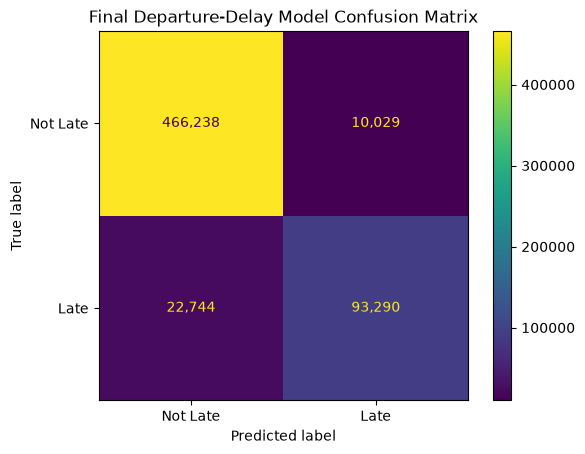

In [18]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

cm = confusion_matrix(y_test, test_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Late", "Late"]
)

disp.plot(values_format=",d")
plt.title("Final Departure-Delay Model Confusion Matrix")
plt.show()

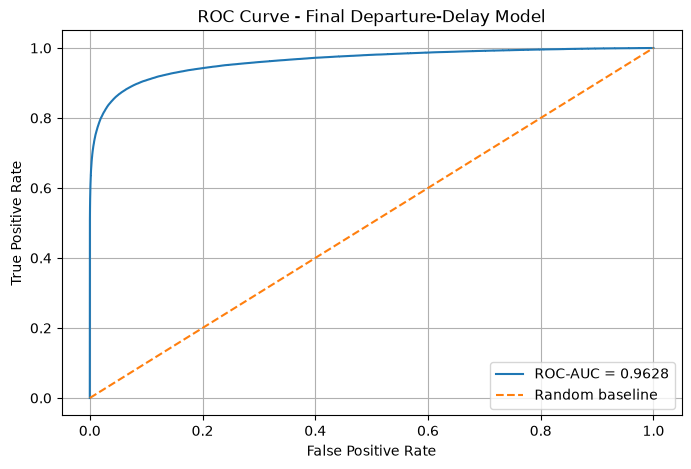

In [19]:
fpr, tpr, roc_thresholds = roc_curve(y_test, test_probs)
roc_auc = roc_auc_score(y_test, test_probs)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Departure-Delay Model")
plt.legend()
plt.grid(True)
plt.show()

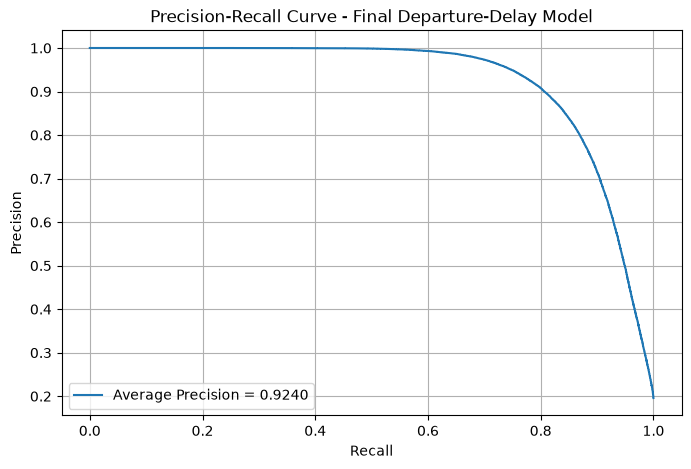

In [20]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, test_probs)
avg_precision = average_precision_score(y_test, test_probs)

plt.figure(figsize=(8, 5))
plt.plot(recall_curve, precision_curve, label=f"Average Precision = {avg_precision:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Final Departure-Delay Model")
plt.legend()
plt.grid(True)
plt.show()

## Error Analysis by Carrier

This section examines false positives and false negatives by airline carrier. False positives are flights predicted late that were not actually late. False negatives are flights predicted not late that were actually late.

In [21]:
test_with_probs["predicted_arrival_delay_15"] = test_preds

test_with_probs["prediction_result"] = np.select(
    [
        (test_with_probs[target] == 0) & (test_with_probs["predicted_arrival_delay_15"] == 0),
        (test_with_probs[target] == 0) & (test_with_probs["predicted_arrival_delay_15"] == 1),
        (test_with_probs[target] == 1) & (test_with_probs["predicted_arrival_delay_15"] == 0),
        (test_with_probs[target] == 1) & (test_with_probs["predicted_arrival_delay_15"] == 1),
    ],
    [
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive",
    ],
    default="Unknown"
)

carrier_errors = (
    test_with_probs
    .groupby("OP_UNIQUE_CARRIER")["prediction_result"]
    .value_counts()
    .unstack(fill_value=0)
)

for col in ["True Negative", "False Positive", "False Negative", "True Positive"]:
    if col not in carrier_errors.columns:
        carrier_errors[col] = 0

carrier_errors["flights"] = carrier_errors.sum(axis=1)

carrier_errors["false_positive_rate"] = (
    carrier_errors["False Positive"] /
    (carrier_errors["False Positive"] + carrier_errors["True Negative"])
).replace([np.inf, -np.inf], np.nan)

carrier_errors["false_negative_rate"] = (
    carrier_errors["False Negative"] /
    (carrier_errors["False Negative"] + carrier_errors["True Positive"])
).replace([np.inf, -np.inf], np.nan)

carrier_errors = carrier_errors.sort_values(
    "false_negative_rate",
    ascending=False
)

carrier_errors

prediction_result,False Negative,False Positive,True Negative,True Positive,flights,false_positive_rate,false_negative_rate
OP_UNIQUE_CARRIER,,,,,,,
AS,1102,397,14806,2451,18756,0.026113,0.310160
HA,301,185,5355,848,6689,0.033394,0.261967
MQ,1082,281,18277,3654,23294,0.015142,0.228463
AA,4241,1535,60765,14502,81043,0.024639,0.226271
DL,3422,1072,67338,12025,83857,0.015670,0.221532
UA,2373,1170,53892,9182,66617,0.021249,0.205366
YX,865,422,23596,3539,28422,0.017570,0.196412
G4,563,128,10165,2391,13247,0.012436,0.190589
NK,656,382,15503,3036,19577,0.024048,0.177681


## Highest-Risk Predicted Flights

The table below shows the flights with the highest predicted probability of arriving at least 15 minutes late. These examples help make the model output more interpretable because they show what high-risk predictions look like at the row level.

In [22]:
preview_columns = [
    "MONTH",
    "DAY_OF_MONTH",
    "DAY_OF_WEEK",
    "OP_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST",
    "DEP_DELAY",
    "DEP_DELAY_NEW",
    "DEP_DEL15",
    "DEP_DELAY_GROUP",
    "TAXI_OUT",
    "WHEELS_OFF",
    "DISTANCE",
    "predicted_delay_probability",
    "predicted_arrival_delay_15",
    "ARR_DEL15",
]

available_preview_columns = [
    col for col in preview_columns
    if col in test_with_probs.columns
]

high_risk_flights = (
    test_with_probs[available_preview_columns]
    .sort_values("predicted_delay_probability", ascending=False)
    .head(20)
)

high_risk_flights

,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,ORIGIN,DEST,DEP_DELAY,DEP_DELAY_NEW,DEP_DEL15,DEP_DELAY_GROUP,TAXI_OUT,WHEELS_OFF,DISTANCE,predicted_delay_probability,predicted_arrival_delay_15,ARR_DEL15
1490029,3,24,1,AA,CMH,CLT,486.0,486.0,1.0,12.0,26.0,1701.0,347.0,0.999927,1,1.0
1488165,3,24,1,AA,RSW,CLT,3288.0,3288.0,1.0,12.0,16.0,1504.0,600.0,0.999914,1,1.0
1622105,3,30,7,WN,BNA,HOU,160.0,160.0,1.0,10.0,12.0,137.0,670.0,0.999904,1,1.0
1508518,3,25,2,AA,CID,CLT,99.0,99.0,1.0,6.0,19.0,833.0,742.0,0.999896,1,1.0
1641854,3,31,1,WN,LAS,HOU,97.0,97.0,1.0,6.0,16.0,2203.0,1235.0,0.999876,1,1.0
1587389,3,29,6,AA,DEN,DFW,234.0,234.0,1.0,12.0,59.0,2325.0,641.0,0.999874,1,1.0
1622475,3,30,7,WN,FLL,HOU,148.0,148.0,1.0,9.0,94.0,2342.0,957.0,0.999866,1,1.0
1621979,3,30,7,WN,MIA,HOU,140.0,140.0,1.0,9.0,74.0,2314.0,955.0,0.999860,1,1.0
1640703,3,31,1,WN,IND,HOU,79.0,79.0,1.0,5.0,8.0,732.0,861.0,0.999856,1,1.0
1614332,3,30,7,MQ,CMI,ORD,88.0,88.0,1.0,5.0,80.0,1557.0,135.0,0.999855,1,1.0


## Final Interpretation Summary

The final departure-delay model performs strongly because actual departure delay is highly predictive of arrival delay. The ROC curve and precision-recall curve show that the model separates late and not-late flights well, while the confusion matrix shows how many late and not-late flights are correctly or incorrectly classified at the selected threshold.

Permutation importance confirms that `DEP_DELAY` is the dominant predictor. `TAXI_OUT` also contributes because long taxi-out times can reduce the time available to recover from a late departure. Route, airport, airline, and scheduled-time features provide additional context, but their effects are much smaller than the direct departure-delay features.

The carrier-level error analysis shows where the model is still imperfect. False negatives are especially important because they represent flights that were actually late but predicted not late. These cases are useful for future improvement, especially if new features such as weather, airport congestion, or aircraft rotation delay are added.

Overall, the interpretation supports the main project conclusion: scheduled-only information has limited future-month predictive power, while actual departure-delay information creates a much stronger arrival-delay prediction model.

## Export Final Interpretation Outputs

The final interpretation visuals and summary tables are saved locally under `visuals/final_model_interpretation/`. These files are not pushed to GitHub because `visuals/` is ignored, but they are useful for screenshots, portfolio writeups, and future reporting.

In [23]:
from pathlib import Path

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

export_dir = PROJECT_ROOT / "visuals" / "final_model_interpretation"
export_dir.mkdir(parents=True, exist_ok=True)

print(f"Export folder: {export_dir}")

Export folder: C:\Users\micha\airline-delay-predictor\visuals\final_model_interpretation


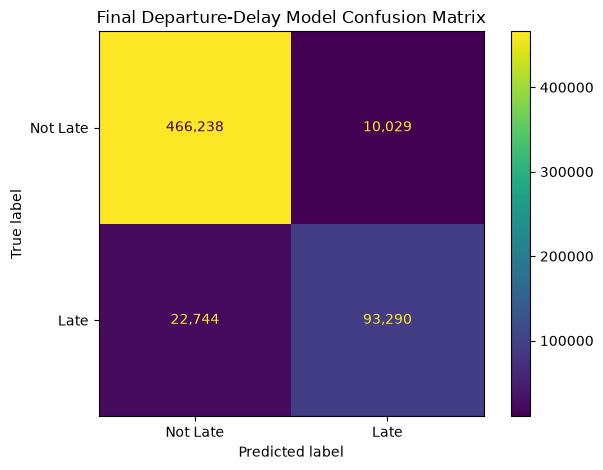

In [24]:
cm = confusion_matrix(y_test, test_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Late", "Late"]
)

disp.plot(values_format=",d")
plt.title("Final Departure-Delay Model Confusion Matrix")
plt.tight_layout()
plt.savefig(export_dir / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

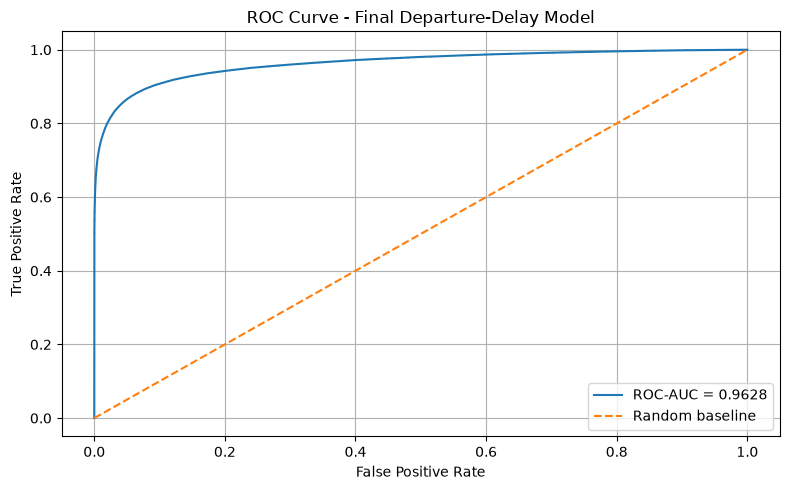

In [25]:
fpr, tpr, roc_thresholds = roc_curve(y_test, test_probs)
roc_auc = roc_auc_score(y_test, test_probs)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Departure-Delay Model")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(export_dir / "roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

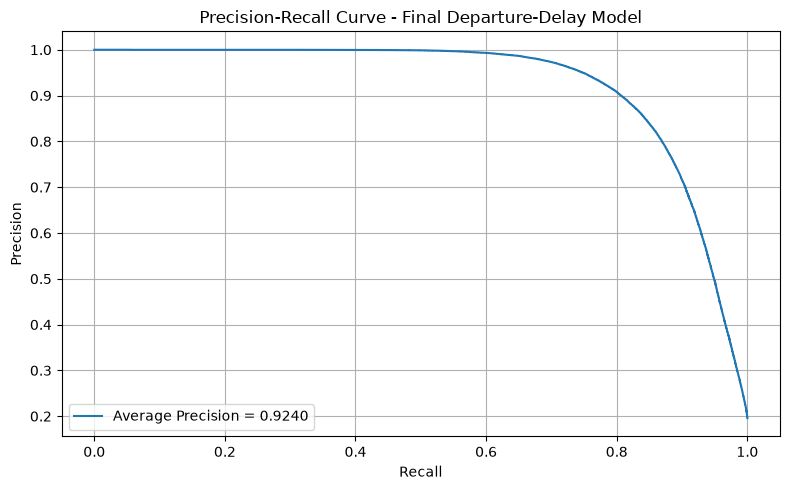

In [26]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, test_probs)
avg_precision = average_precision_score(y_test, test_probs)

plt.figure(figsize=(8, 5))
plt.plot(recall_curve, precision_curve, label=f"Average Precision = {avg_precision:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Final Departure-Delay Model")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(export_dir / "precision_recall_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [27]:
# Make sure prediction columns exist.
if "predicted_arrival_delay_15" not in test_with_probs.columns:
    test_with_probs["predicted_arrival_delay_15"] = test_preds

if "predicted_delay_probability" not in test_with_probs.columns:
    test_with_probs["predicted_delay_probability"] = test_probs

# Save carrier error table if it exists.
if "carrier_errors" in globals():
    carrier_errors.to_csv(export_dir / "carrier_error_analysis.csv")

# Save highest-risk flights if it exists.
if "high_risk_flights" in globals():
    high_risk_flights.to_csv(export_dir / "highest_risk_predicted_flights.csv", index=False)

# Save a compact prediction output sample.
prediction_sample_columns = [
    "MONTH",
    "DAY_OF_MONTH",
    "DAY_OF_WEEK",
    "OP_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST",
    "DEP_DELAY",
    "TAXI_OUT",
    "DISTANCE",
    "predicted_delay_probability",
    "predicted_arrival_delay_15",
    "ARR_DEL15",
]

available_prediction_sample_columns = [
    col for col in prediction_sample_columns
    if col in test_with_probs.columns
]

prediction_sample = test_with_probs[available_prediction_sample_columns].head(100)
prediction_sample.to_csv(export_dir / "prediction_sample_100_rows.csv", index=False)

print("Saved final interpretation outputs:")
for path in sorted(export_dir.iterdir()):
    print(f"- {path.name}")

Saved final interpretation outputs:
- carrier_error_analysis.csv
- confusion_matrix.png
- highest_risk_predicted_flights.csv
- precision_recall_curve.png
- prediction_sample_100_rows.csv
- roc_curve.png
